In [17]:
# PHASE 2 : MORE FEATURES THAN PHASE 1
# This script demonstrates additional features compared to Phase 1.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from  sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [19]:
# LOAD THE DATA
df = pd.read_csv('combined_solar_radiation.csv')
print(df.head(10))

   Year  Month  Day  Hour  Minute  DHI  DNI  GHI  Clearsky DHI  Clearsky DNI  \
0  2000      1    1     0       0    0    0    0             0             0   
1  2000      1    1     1       0    0    0    0             0             0   
2  2000      1    1     2       0    0    0    0             0             0   
3  2000      1    1     3       0    0    0    0             0             0   
4  2000      1    1     4       0    0    0    0             0             0   
5  2000      1    1     5       0    0    0    0             0             0   
6  2000      1    1     6       0    0    0    0             2             7   
7  2000      1    1     7       0   65  313  114            59           386   
8  2000      1    1     8       0  102  594  302           100           650   
9  2000      1    1     9       0  129  747  489           122           773   

   ...  Temperature  Pressure  Relative Humidity  Solar Zenith Angle  \
0  ...            5       890              83.3

In [20]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131496 entries, 0 to 131495
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Year                131496 non-null  int64  
 1   Month               131496 non-null  int64  
 2   Day                 131496 non-null  int64  
 3   Hour                131496 non-null  int64  
 4   Minute              131496 non-null  int64  
 5   DHI                 131496 non-null  int64  
 6   DNI                 131496 non-null  int64  
 7   GHI                 131496 non-null  int64  
 8   Clearsky DHI        131496 non-null  int64  
 9   Clearsky DNI        131496 non-null  int64  
 10  Clearsky GHI        131496 non-null  int64  
 11  Dew Point           131496 non-null  int64  
 12  Temperature         131496 non-null  int64  
 13  Pressure            131496 non-null  int64  
 14  Relative Humidity   131496 non-null  float64
 15  Solar Zenith Angle  131496 non-nul

In [21]:
print(df.describe())

                Year          Month            Day           Hour    Minute  \
count  131496.000000  131496.000000  131496.000000  131496.000000  131496.0   
mean     2006.999270       6.522723      15.730243      11.500000       0.0   
std         4.320707       3.448773       8.800381       6.922213       0.0   
min      2000.000000       1.000000       1.000000       0.000000       0.0   
25%      2003.000000       4.000000       8.000000       5.750000       0.0   
50%      2007.000000       7.000000      16.000000      11.500000       0.0   
75%      2011.000000      10.000000      23.000000      17.250000       0.0   
max      2014.000000      12.000000      31.000000      23.000000       0.0   

                 DHI            DNI            GHI   Clearsky DHI  \
count  131496.000000  131496.000000  131496.000000  131496.000000   
mean       92.885593     179.538503     211.019666      75.107730   
std       120.882359     277.967916     292.640651      89.936189   
min         

In [22]:
print(df.isnull().sum())

Year                  0
Month                 0
Day                   0
Hour                  0
Minute                0
DHI                   0
DNI                   0
GHI                   0
Clearsky DHI          0
Clearsky DNI          0
Clearsky GHI          0
Dew Point             0
Temperature           0
Pressure              0
Relative Humidity     0
Solar Zenith Angle    0
Precipitable Water    0
Snow Depth            0
Wind Direction        0
Wind Speed            0
Fill Flag             0
SourceFile            0
dtype: int64


In [23]:
# DATA PREPROCESSING

In [24]:
# Create the datetime column
df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

# Extract additional time-based features
df['Hour_of_Day'] = df['datetime'].dt.hour 
df['Day_of_Year'] = df['datetime'].dt.dayofyear

# create cyclic-time encoding
df['Sin_hour'] = np.sin(2 * np.pi * df['Hour_of_Day'] / 24)
df['Cos_hour'] = np.cos(2 * np.pi * df['Hour_of_Day'] / 24)
df['Sin_day'] = np.sin(2 * np.pi * df['Day_of_Year'] / 365)
df['Cos_day'] = np.cos(2 * np.pi * df['Day_of_Year'] / 365)


In [25]:
# FFilter daytime hours (GHI > 0)
inital_count = len(df)
df = df[df['GHI'] > 0].copy()
filtered = inital_count - len(df)
print(f"Filtered out {filtered} rows with GHI <= 0")


Filtered out 66031 rows with GHI <= 0


In [26]:
# Create target variable

panel_efficiency = 0.18
panel_area = 1000 # in square meters
temperature_coefficient = -0.004 # efficiency drop per degree Celsius above 25C

#calculate temperature loss factor
df['Temp_loss_factor'] = 1 + temperature_coefficient * (df['Temperature'] - 25)
#calculate Power output
df['Power_Output'] = df['GHI'] * panel_area * panel_efficiency * df['Temp_loss_factor'] / 1000  # in kW 

#ensure no negative power output
df['power_output'] = df['Power_Output'].clip(lower=0)

In [27]:
# FEATURE SELECTION
features = [
    'GHI',                  # Primary predictor
    'DNI',                  # Direct irradiance
    'Temperature',          # Panel efficiency factor
    'Solar Zenith Angle',   # Sun position
    'Day_of_Year',          # Seasonal pattern
    'Hour_of_Day',          # Diurnal pattern
    'DHI',                  # Diffuse irradiance
    'Relative Humidity',    # Weather condition
    'Wind Speed',           # Cooling effect
    'Wind Direction',       # Weather condition
    'Pressure',             # Atmospheric pressure
    'Dew Point'             # Moisture content
]
#available features
features_av = [f for f in features if f in df.columns]

print(f"Core Features ({len(features_av)} selected):")
for i, feature in enumerate(features_av, 1):
    print(f"  {i}. {feature}")

X = df[features_av]
y = df['Power_Output']

print(f"Features matrix: {X.shape}")
print(f"Target vector: {y.shape}")

Core Features (12 selected):
  1. GHI
  2. DNI
  3. Temperature
  4. Solar Zenith Angle
  5. Day_of_Year
  6. Hour_of_Day
  7. DHI
  8. Relative Humidity
  9. Wind Speed
  10. Wind Direction
  11. Pressure
  12. Dew Point
Features matrix: (65465, 12)
Target vector: (65465,)


In [28]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Testing set: {X_test.shape}, {y_test.shape}")

Training set: (52372, 12), (52372,)
Testing set: (13093, 12), (13093,)


In [29]:
# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# MODEL TRAINING
model = LinearRegression() 
model.fit(X_train_scaled, y_train)
# MODEL EVALUATION
y_train_pred = model.predict(X_train_scaled)   
y_test_pred = model.predict(X_test_scaled)   

In [31]:
# calculate metrics
train_r = r2_score(y_train, y_train_pred)
test_r = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

In [32]:
print(f"  Features:      {len(features_av)}")
print(f"  Train R²:      {train_r:.4f}")
print(f"  Test R²:       {test_r:.4f}")
print(f"  Test RMSE:     {test_rmse:.2f} kW")
print(f"  Test MAE:      {test_mae:.2f} kW")
print(f"  Overfitting:   {train_r - test_r:.4f}")
print(f"  Train RMSE:    {train_rmse:.2f} kW")
print(f"  Train MAE:     {train_mae:.2f} kW")


  Features:      12
  Train R²:      0.9998
  Test R²:       0.9997
  Test RMSE:     0.93 kW
  Test MAE:      0.71 kW
  Overfitting:   0.0001
  Train RMSE:    0.81 kW
  Train MAE:     0.62 kW


In [33]:
# PERFORMANCE METRICS
print("\n1. R² Score (Coefficient of Determination):")
print(f"   Train R²: {train_r:.4f}")
print(f"   Test R²:  {test_r:.4f}")
print(f"   Model explains {test_r*100:.2f}% of variance in solar output")

print("\n2. Root Mean Squared Error (RMSE):")
print(f"   Train RMSE: {train_rmse:.2f} kW")
print(f"   Test RMSE:  {test_rmse:.2f} kW")
print(f"   Average prediction error: ±{test_rmse:.2f} kW")

print("\n3. Mean Absolute Error (MAE):")
print(f"   Test MAE: {test_mae:.2f} kW")
print(f"   Average absolute error: {test_mae:.2f} kW")


1. R² Score (Coefficient of Determination):
   Train R²: 0.9998
   Test R²:  0.9997
   Model explains 99.97% of variance in solar output

2. Root Mean Squared Error (RMSE):
   Train RMSE: 0.81 kW
   Test RMSE:  0.93 kW
   Average prediction error: ±0.93 kW

3. Mean Absolute Error (MAE):
   Test MAE: 0.71 kW
   Average absolute error: 0.71 kW


In [34]:
# Overfitting check
r2_diff = train_r - test_r
print("\n" + "-" * 80)
print("🔍 OVERFITTING ANALYSIS:")
print(f"   R² difference (Train - Test): {r2_diff:.4f}")

if r2_diff < 0.02:
    verdict = "✓ Excellent - No overfitting detected"
elif r2_diff < 0.05:
    verdict = "✓ Good - Minimal overfitting"
elif r2_diff < 0.10:
    verdict = "⚠ Acceptable - Slight overfitting"
else:
    verdict = "✗ Warning - Significant overfitting detected"

print(f"   {verdict}")


--------------------------------------------------------------------------------
🔍 OVERFITTING ANALYSIS:
   R² difference (Train - Test): 0.0001
   ✓ Excellent - No overfitting detected


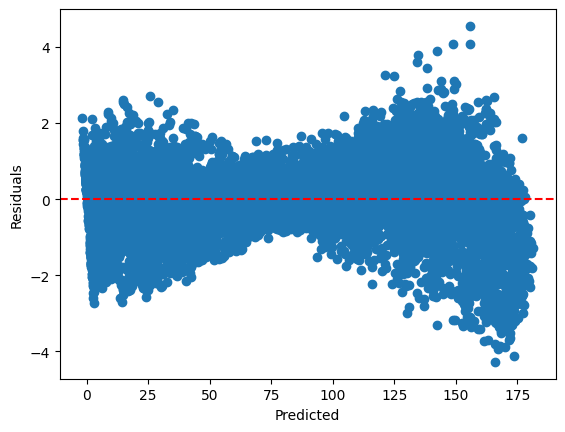

In [35]:
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()


In [36]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': features_av,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(feature_importance[['Feature', 'Coefficient']].to_string(index=False))



           Feature  Coefficient
               GHI    50.465364
               DNI     1.601739
       Temperature    -1.592595
         Dew Point     1.221346
 Relative Humidity    -0.910149
               DHI     0.864125
Solar Zenith Angle    -0.092504
       Hour_of_Day     0.071827
    Wind Direction    -0.071766
       Day_of_Year    -0.062431
          Pressure     0.036065
        Wind Speed    -0.005189


In [37]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

Text(0.05, 0.95, 'R² = 0.9997')

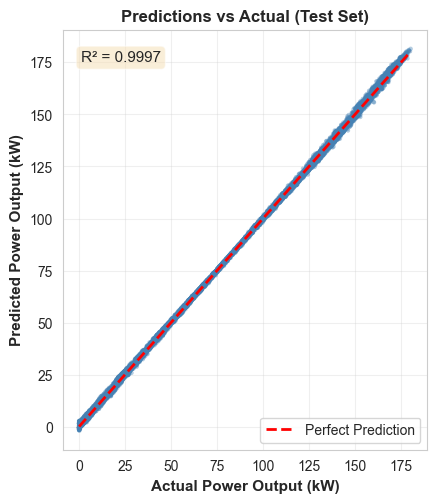

In [38]:
fig = plt.figure(figsize=(16, 12))

# 1. Predictions vs Actual (Test Set)
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, y_test_pred, alpha=0.4, s=10, c='steelblue', edgecolors='none')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Power Output (kW)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted Power Output (kW)', fontsize=11, fontweight='bold')
ax1.set_title('Predictions vs Actual (Test Set)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'R² = {test_r:.4f}', transform=ax1.transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


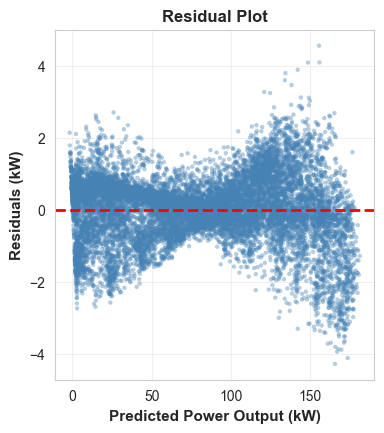

In [39]:
# 2. Residual Plot
ax2 = plt.subplot(2, 3, 2)
residuals = y_test - y_test_pred
ax2.scatter(y_test_pred, residuals, alpha=0.4, s=10, c='steelblue', edgecolors='none')
ax2.axhline(y=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Predicted Power Output (kW)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals (kW)', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

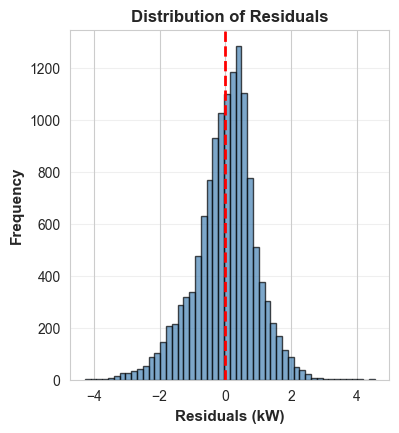

In [40]:
# 3. Residual Distribution
ax3 = plt.subplot(2, 3, 3)
ax3.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(x=0, color='r', linestyle='--', lw=2)
ax3.set_xlabel('Residuals (kW)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

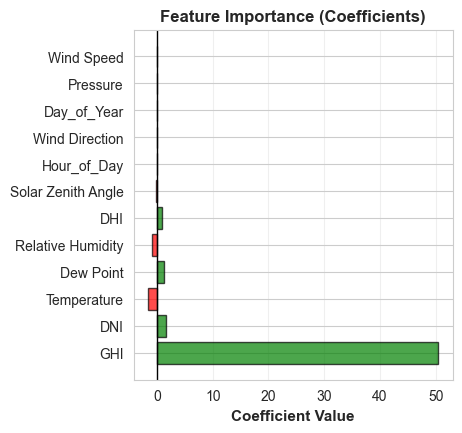

In [41]:
# 4. Feature Importance
ax4 = plt.subplot(2, 3, 4)
colors = ['green' if c > 0 else 'red' for c in feature_importance['Coefficient']]
bars = ax4.barh(feature_importance['Feature'], feature_importance['Coefficient'], 
                color=colors, alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='black', linestyle='-', lw=1)
ax4.set_xlabel('Coefficient Value', fontsize=11, fontweight='bold')
ax4.set_title('Feature Importance (Coefficients)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

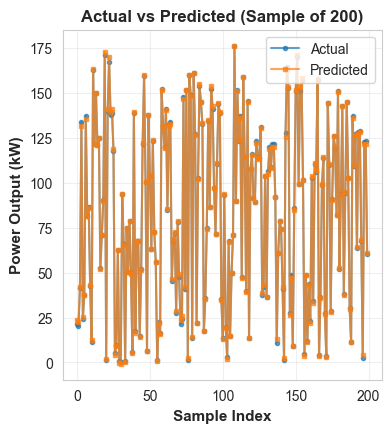

In [42]:
# 5. Actual vs Predicted Time Series (Sample)
ax5 = plt.subplot(2, 3, 5)
sample_size = min(200, len(y_test))
sample_indices = np.random.choice(len(y_test), sample_size, replace=False)
sample_indices = np.sort(sample_indices)
ax5.plot(range(sample_size), y_test.iloc[sample_indices].values, 
         'o-', label='Actual', alpha=0.7, markersize=3)
ax5.plot(range(sample_size), y_test_pred[sample_indices], 
         's-', label='Predicted', alpha=0.7, markersize=3)
ax5.set_xlabel('Sample Index', fontsize=11, fontweight='bold')
ax5.set_ylabel('Power Output (kW)', fontsize=11, fontweight='bold')
ax5.set_title(f'Actual vs Predicted (Sample of {sample_size})', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

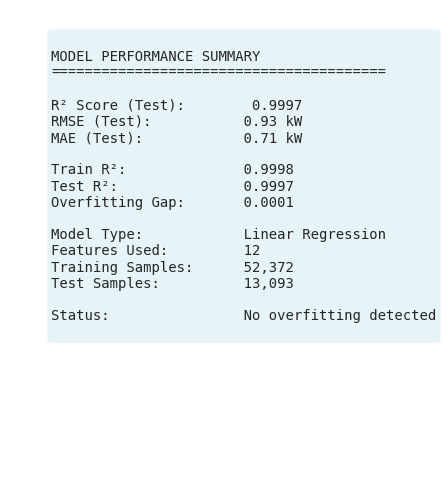

In [43]:
# 6. Error Metrics Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
metrics_text = f"""
MODEL PERFORMANCE SUMMARY
{'='*40}

R² Score (Test):        {test_r:.4f}
RMSE (Test):           {test_rmse:.2f} kW
MAE (Test):            {test_mae:.2f} kW

Train R²:              {train_r:.4f}
Test R²:               {test_r:.4f}
Overfitting Gap:       {r2_diff:.4f}

Model Type:            Linear Regression
Features Used:         {len(features_av)}
Training Samples:      {len(X_train):,}
Test Samples:          {len(X_test):,}

Status:                {verdict.split('-')[1].strip()}
"""
ax6.text(0.1, 0.95, metrics_text, transform=ax6.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
# plt.savefig('phase1_solar_regression_results.png', dpi=300)
plt.show()